# HealthAI Coach — Pipeline Machine Learning
### Recommandation de programmes sportifs personnalisés

**Auteur :** MSPR CDA / Développeur IA  
**Objectif :** Prédire le profil fitness d'un utilisateur à partir de ses données biométriques et lui recommander un programme sportif adapté.

---
**Pipeline :**
1. EDA — Exploration des données
2. Nettoyage
3. Feature Engineering & Preprocessing
4. Modélisation & RandomSearch
5. Évaluation (Metrics, Confusion Matrix, Learning Curve)
6. Feature Importance & Interprétation
7. MLflow — Tracking des expériences

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

# Ajouter la racine au path
ROOT = Path().resolve().parent.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'ml'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='husl')

print('Environnement OK')

Environnement OK


---
## 1. Chargement des données

In [2]:
DATA_PATH = ROOT / 'ml' / 'data' / 'processed' / 'healthai_dataset.csv'
df_raw = pd.read_csv(DATA_PATH)

print(f'Shape : {df_raw.shape}')
print(f'Colonnes : {list(df_raw.columns)}')
df_raw.head(10)

Shape : (2000, 9)
Colonnes : ['age', 'gender', 'weight_kg', 'height_cm', 'bmi', 'body_fat_pct', 'resting_bpm', 'experience_level', 'fitness_profile']


,age,gender,weight_kg,height_cm,bmi,body_fat_pct,resting_bpm,experience_level,fitness_profile
0,33,1,59.1,168.3,20.88,9.1,69,2,prise_masse_confirme
1,58,0,54.5,152.8,23.35,22.0,68,2,prise_masse_confirme
2,19,1,86.0,177.9,27.18,17.4,80,1,amelioration_cardio
3,39,1,81.0,171.6,27.50,21.3,75,2,perte_poids_confirme
4,56,0,89.3,160.7,34.58,32.1,80,1,perte_poids_debutant
5,63,1,77.2,179.1,24.07,9.8,75,2,prise_masse_confirme
6,30,1,72.8,173.6,24.18,18.5,80,2,amelioration_cardio
7,49,1,84.5,177.6,26.78,16.3,78,1,amelioration_cardio
8,27,0,61.6,156.8,25.03,22.8,82,1,maintien_bien_etre
9,23,0,60.0,162.8,22.63,21.0,72,2,prise_masse_confirme


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               2000 non-null   int64  
 1   gender            2000 non-null   int64  
 2   weight_kg         2000 non-null   float64
 3   height_cm         2000 non-null   float64
 4   bmi               2000 non-null   float64
 5   body_fat_pct      2000 non-null   float64
 6   resting_bpm       2000 non-null   int64  
 7   experience_level  2000 non-null   int64  
 8   fitness_profile   2000 non-null   object 
dtypes: float64(4), int64(4), object(1)
memory usage: 140.8+ KB


---
## 2. EDA — Analyse Exploratoire

### 2.1 Statistiques descriptives

In [4]:
df_raw.describe().round(2)

,age,gender,weight_kg,height_cm,bmi,body_fat_pct,resting_bpm,experience_level
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.0,2000.00
mean,41.24,0.52,74.85,169.84,25.86,20.22,71.8,1.63
std,13.82,0.50,15.34,9.36,4.35,6.35,7.9,0.72
min,18.00,0.00,39.00,150.00,16.00,5.00,45.0,1.00
25%,30.00,0.00,64.30,162.50,22.77,15.90,67.0,1.00
50%,41.00,1.00,73.00,169.40,25.44,20.05,72.0,1.00
75%,53.00,1.00,83.52,176.50,28.68,24.60,78.0,2.00
max,65.00,1.00,137.10,198.70,42.96,48.10,97.0,3.00


### 2.2 Distribution des classes (variable cible)

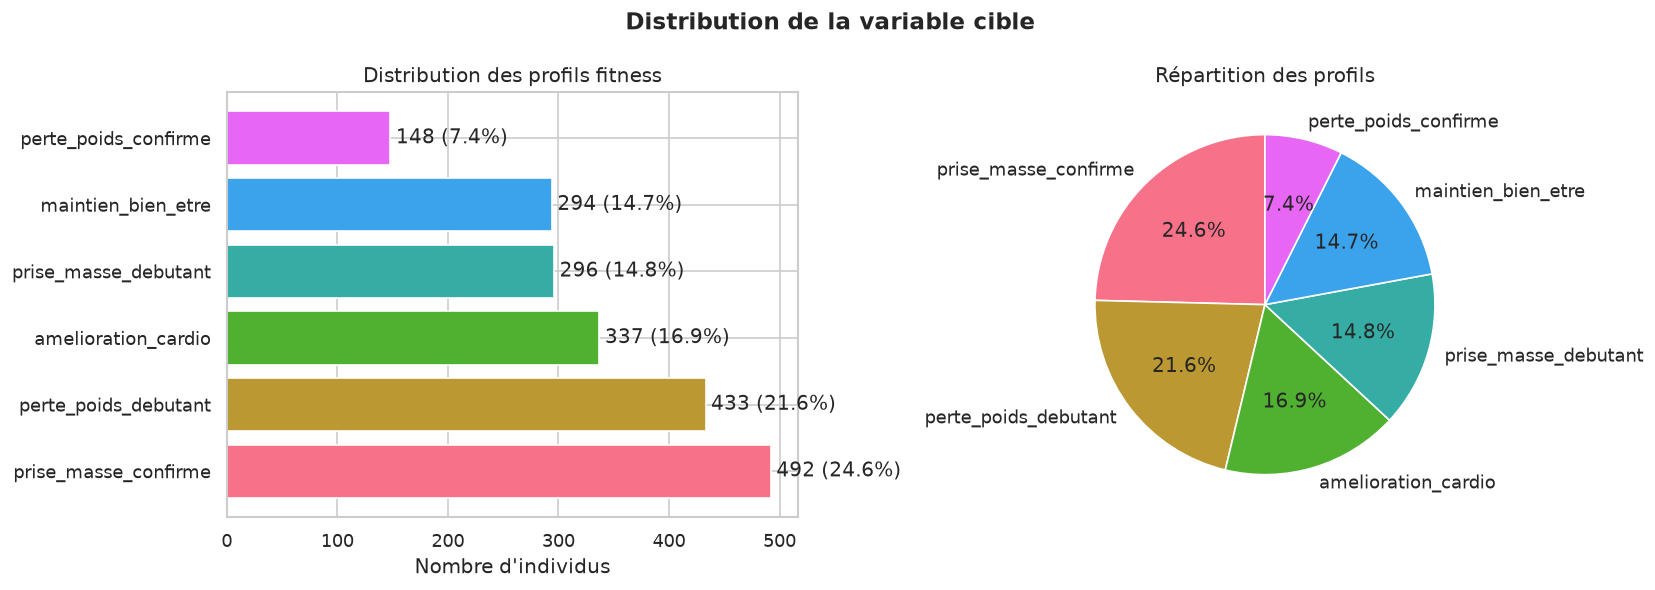

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df_raw['fitness_profile'].value_counts()

# Bar chart
axes[0].barh(counts.index, counts.values, color=sns.color_palette('husl', len(counts)))
axes[0].set_xlabel('Nombre d\'individus')
axes[0].set_title('Distribution des profils fitness')
for i, v in enumerate(counts.values):
    axes[0].text(v + 5, i, f'{v} ({v/len(df_raw)*100:.1f}%)', va='center')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('husl', len(counts)), startangle=90)
axes[1].set_title('Répartition des profils')

plt.suptitle('Distribution de la variable cible', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.3 Distributions des features numériques

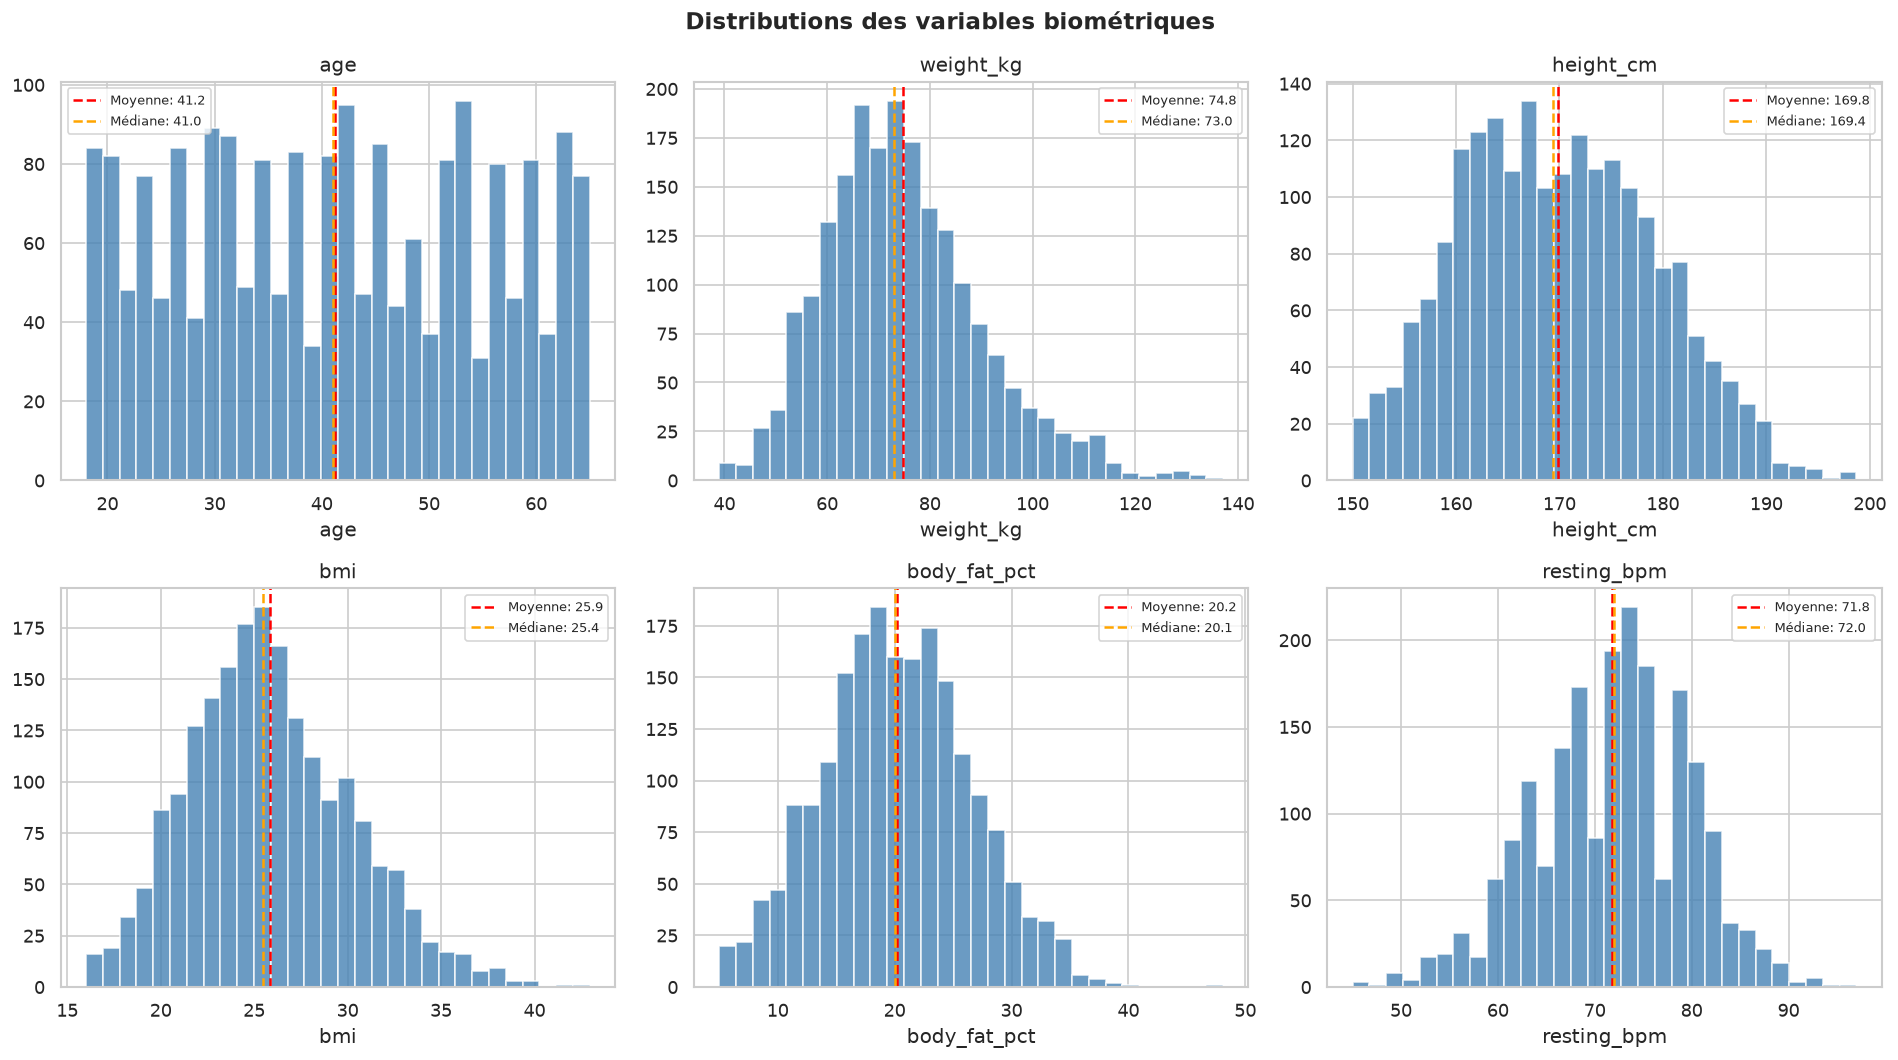

In [6]:
num_cols = ['age', 'weight_kg', 'height_cm', 'bmi', 'body_fat_pct', 'resting_bpm']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df_raw[col], bins=30, edgecolor='white', color='steelblue', alpha=0.8)
    ax.axvline(df_raw[col].mean(), color='red', linestyle='--', label=f'Moyenne: {df_raw[col].mean():.1f}')
    ax.axvline(df_raw[col].median(), color='orange', linestyle='--', label=f'Médiane: {df_raw[col].median():.1f}')
    ax.set_title(col)
    ax.legend(fontsize=8)
    ax.set_xlabel(col)

plt.suptitle('Distributions des variables biométriques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Distributions par profil (boxplots)

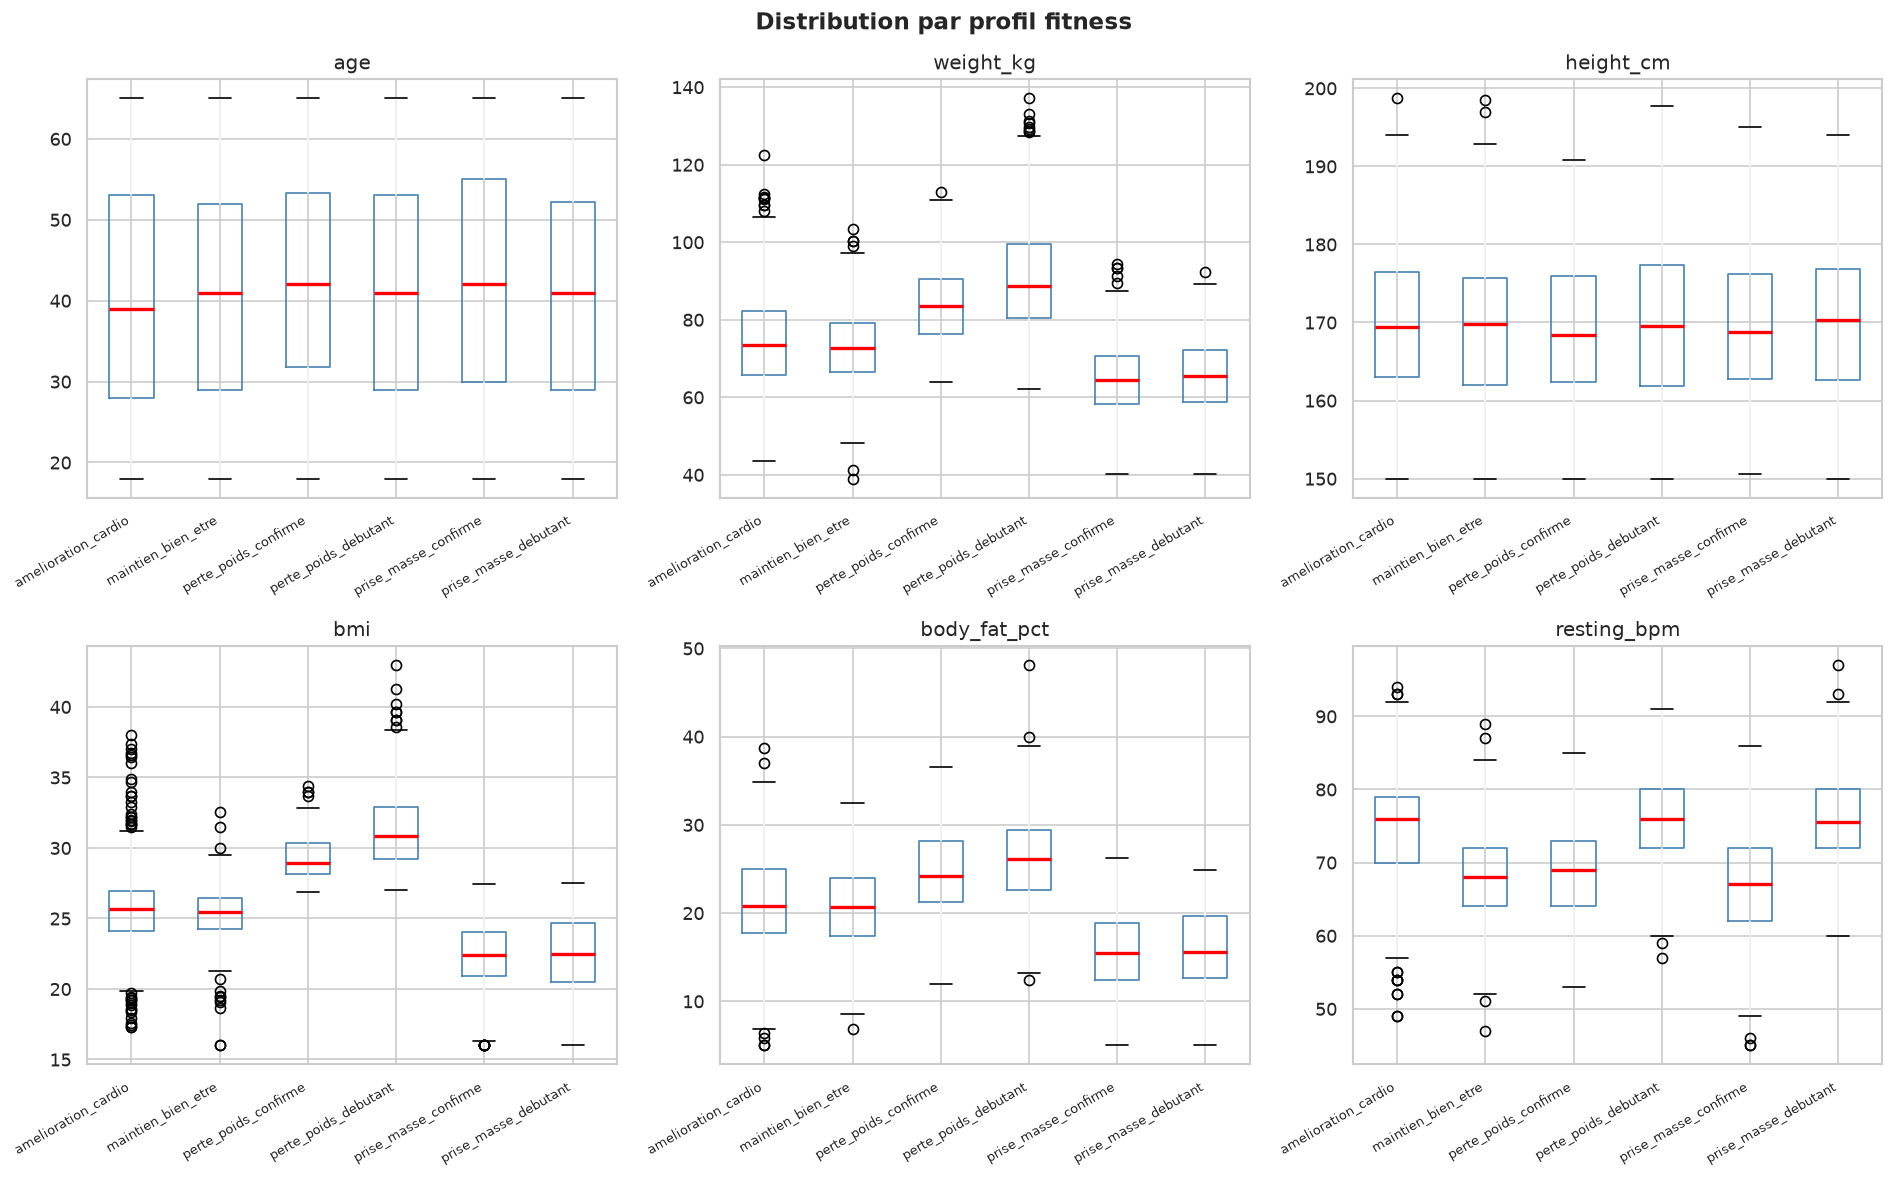

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    df_raw.boxplot(column=col, by='fitness_profile', ax=ax,
                   boxprops=dict(color='steelblue'),
                   medianprops=dict(color='red', linewidth=2))
    ax.set_title(col)
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.suptitle('Distribution par profil fitness', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Matrice de corrélation

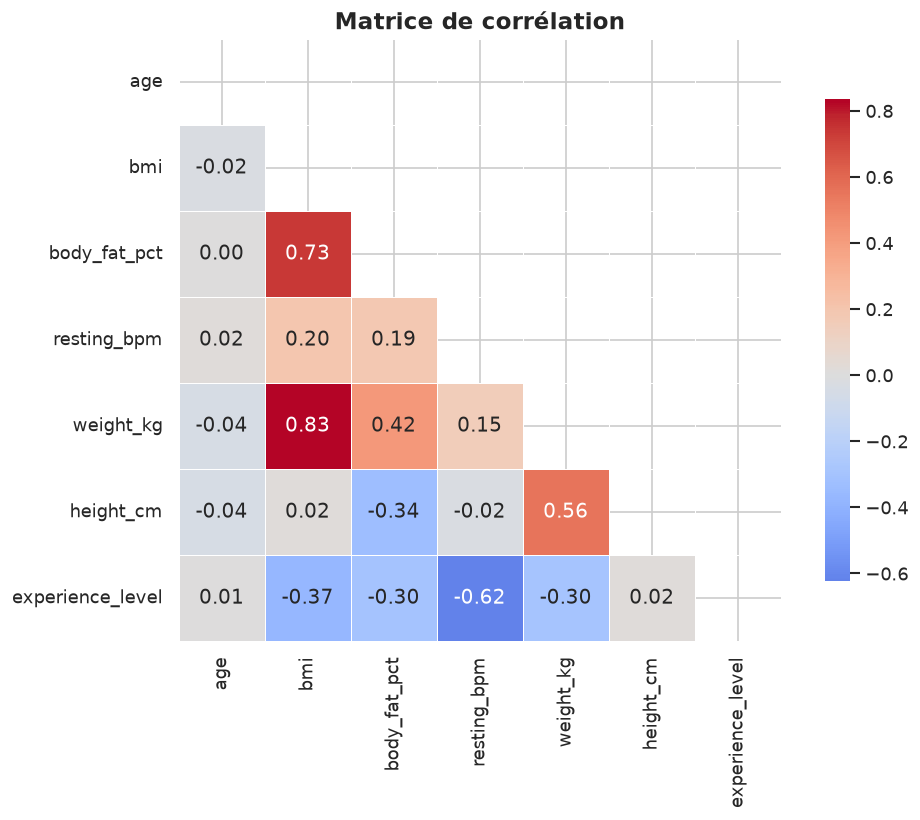

Observation : BMI et body_fat_pct corrélés (~0.6-0.8) — multicolinéarité attendue.
Les deux features sont conservées : fat% = composition corporelle, BMI = rapport poids/taille.


In [8]:
corr_cols = ['age', 'bmi', 'body_fat_pct', 'resting_bpm', 'weight_kg', 'height_cm', 'experience_level']
corr = df_raw[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observation : BMI et body_fat_pct corrélés (~0.6-0.8) — multicolinéarité attendue.')
print('Les deux features sont conservées : fat% = composition corporelle, BMI = rapport poids/taille.')

### 2.6 Détection des outliers (boxplots IQR)

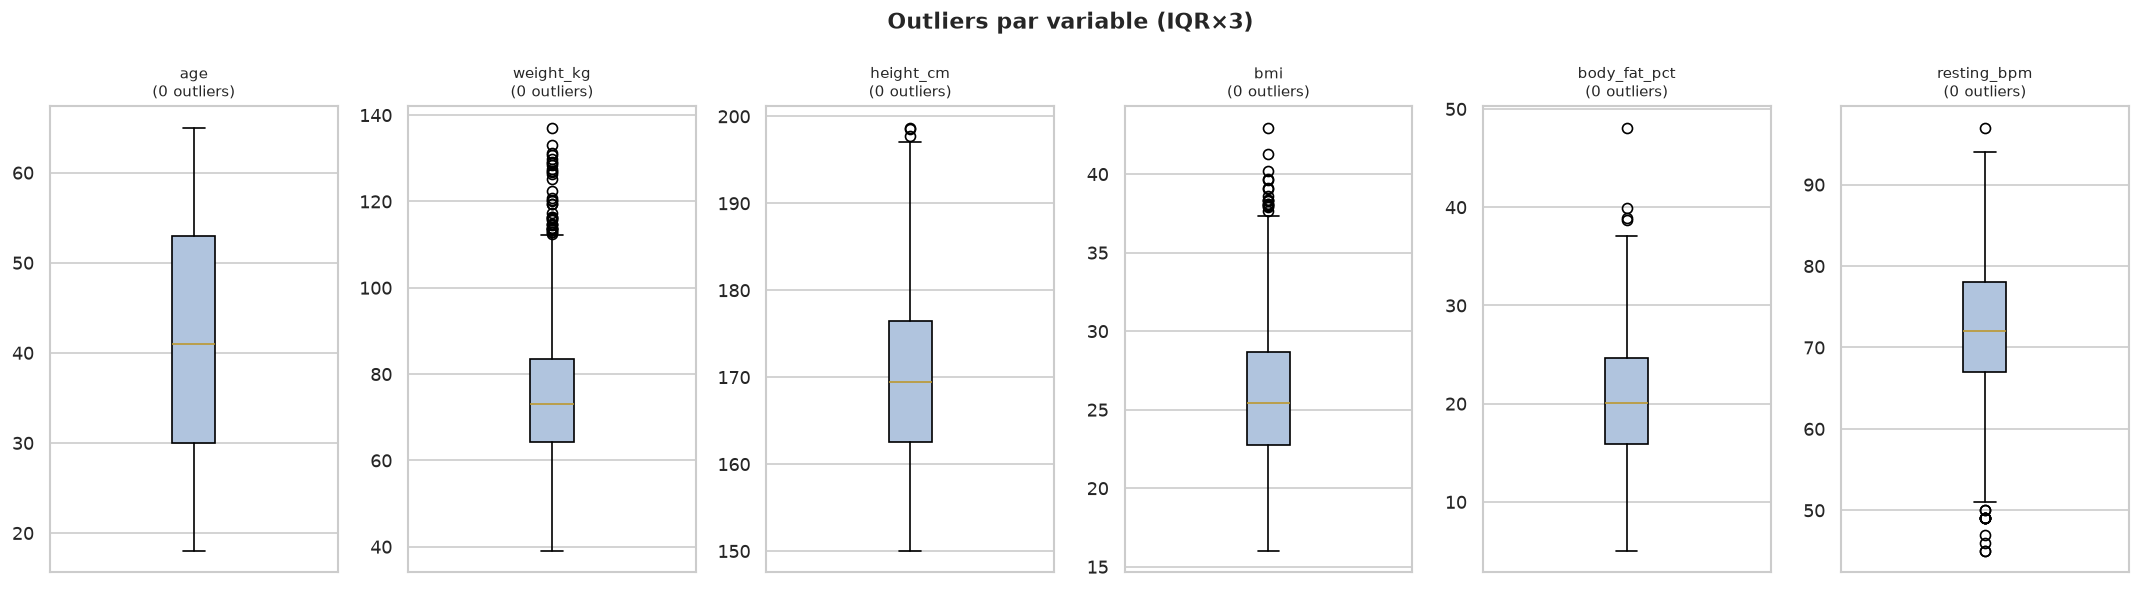

In [9]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5))
for i, col in enumerate(num_cols):
    q1, q3 = df_raw[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = df_raw[(df_raw[col] < q1 - 3*iqr) | (df_raw[col] > q3 + 3*iqr)]
    axes[i].boxplot(df_raw[col], patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue'))
    axes[i].set_title(f'{col}\n({len(outliers)} outliers)', fontsize=9)
    axes[i].set_xticks([])

plt.suptitle('Outliers par variable (IQR×3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.7 Répartition par genre et expérience

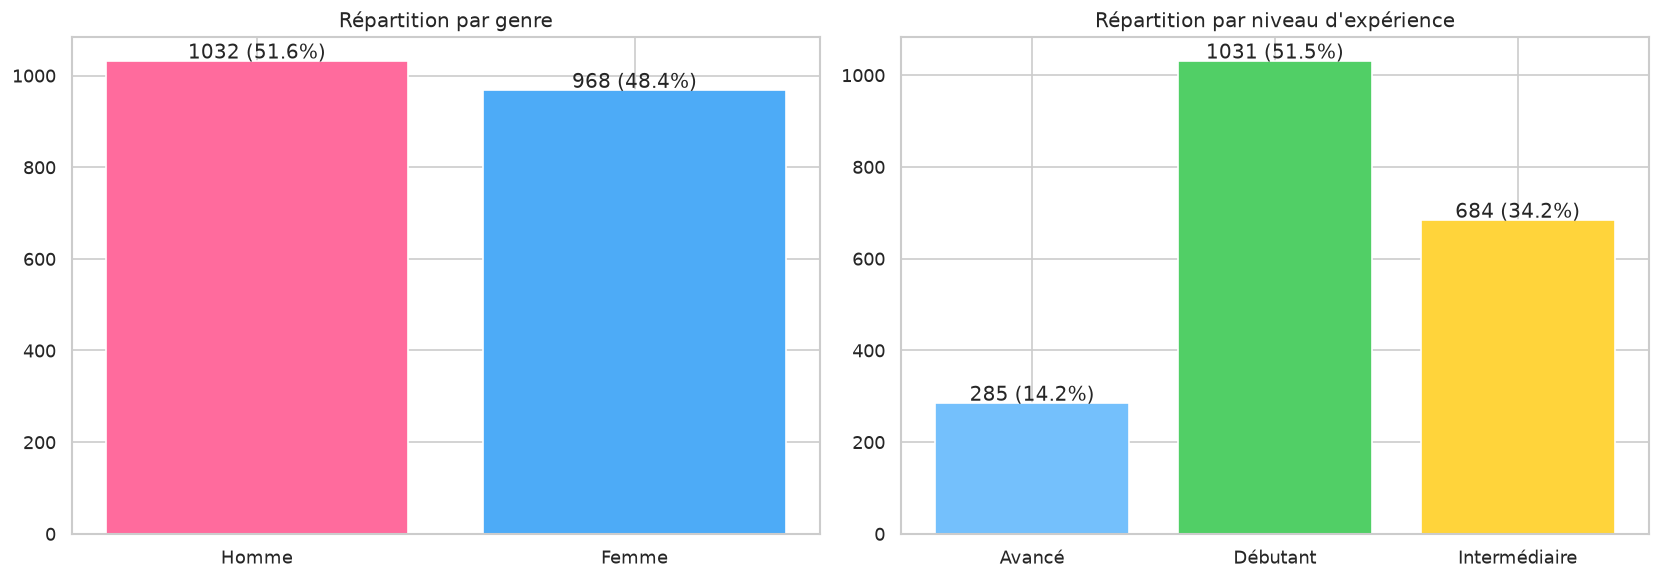

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Genre
gender_counts = df_raw['gender'].map({0: 'Femme', 1: 'Homme'}).value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#ff6b9d', '#4dabf7'])
axes[0].set_title('Répartition par genre')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 5, f'{v} ({v/len(df_raw)*100:.1f}%)', ha='center')

# Niveau expérience
exp_counts = df_raw['experience_level'].map({1: 'Débutant', 2: 'Intermédiaire', 3: 'Avancé'}).value_counts().sort_index()
axes[1].bar(exp_counts.index, exp_counts.values, color=['#74c0fc', '#51cf66', '#ffd43b'])
axes[1].set_title('Répartition par niveau d\'expérience')
for i, v in enumerate(exp_counts.values):
    axes[1].text(i, v + 5, f'{v} ({v/len(df_raw)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

---
## 3. Nettoyage

In [11]:
from src.preprocessing.cleaner import clean

print(f'Avant nettoyage : {df_raw.shape}')
df_clean = clean(df_raw.copy())
print(f'Après nettoyage : {df_clean.shape}')

# Valeurs manquantes
print(f'\nValeurs manquantes : {df_clean.isnull().sum().sum()}')
print(f'Doublons : {df_clean.duplicated().sum()}')

Avant nettoyage : (2000, 9)
[cleaner] Début nettoyage ...
[cleaner] Dataset propre : 2000 lignes
Après nettoyage : (2000, 9)

Valeurs manquantes : 0
Doublons : 0


---
## 4. Feature Engineering

In [12]:
from src.preprocessing.engineer import engineer

df_engineered = engineer(df_clean.copy())

new_features = ['bmi_category', 'fat_category', 'hr_zone', 'fitness_score', 'age_group', 'bmi_x_exp', 'fat_per_exp']
print(f'Features originales : {len(df_clean.columns)}')
print(f'Features après engineering : {len(df_engineered.columns)}')
print(f'\nNouvelles features : {new_features}')
df_engineered[new_features].head()

[engineer] Feature engineering ...
[engineer] 7 features créées : ['bmi_category', 'fat_category', 'hr_zone', 'fitness_score', 'age_group', 'bmi_x_exp', 'fat_per_exp']
Features originales : 9
Features après engineering : 16

Nouvelles features : ['bmi_category', 'fat_category', 'hr_zone', 'fitness_score', 'age_group', 'bmi_x_exp', 'fat_per_exp']


,bmi_category,fat_category,hr_zone,fitness_score,age_group,bmi_x_exp,fat_per_exp
0,normal,athlete,bon,80.26,26-35,41.76,4.55
1,normal,fitness,bon,72.76,56-65,46.70,11.00
2,surpoids,fitness,sous_optimal,51.77,18-25,27.18,17.40
3,surpoids,acceptable,moyen,61.37,36-45,55.00,10.65
4,obesite,obese,sous_optimal,28.44,56-65,34.58,32.10


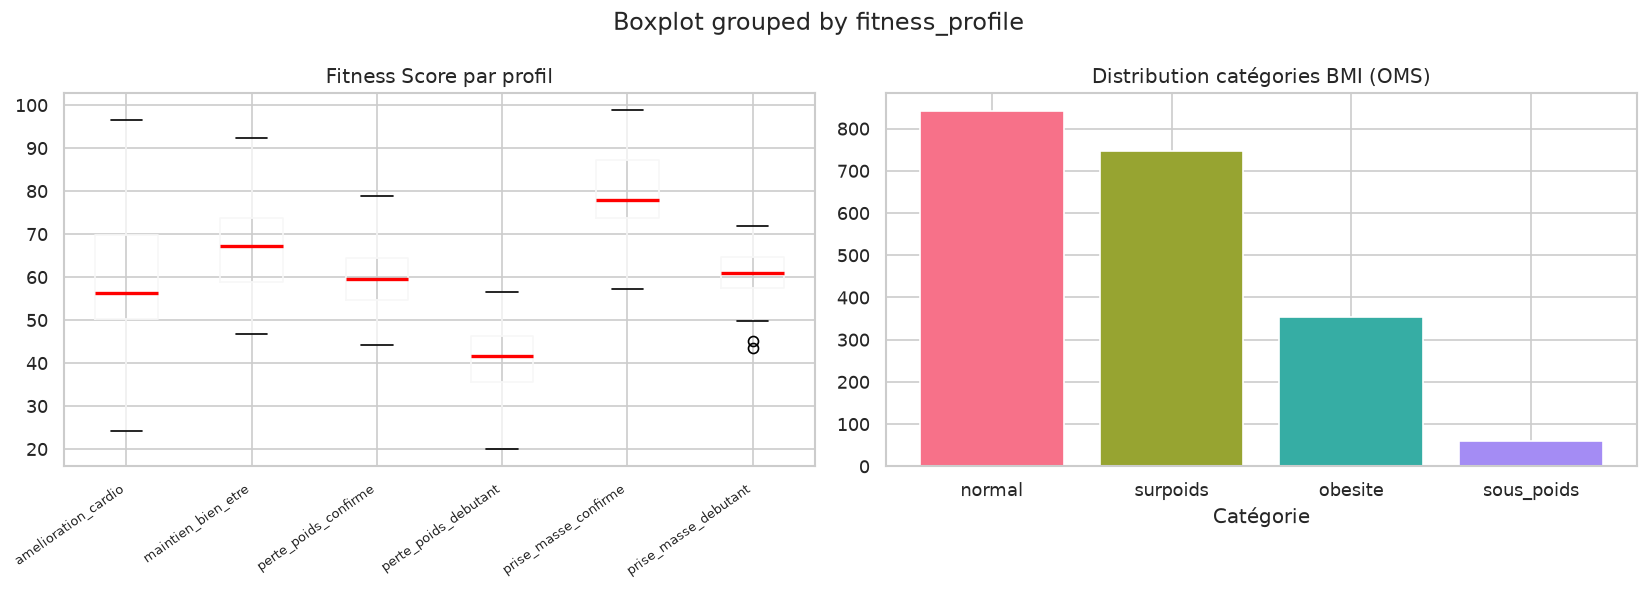

In [13]:
# Fitness Score par profil
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_engineered.boxplot(column='fitness_score', by='fitness_profile', ax=axes[0],
                      medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Fitness Score par profil')
axes[0].set_xlabel('')
plt.setp(axes[0].get_xticklabels(), rotation=35, ha='right', fontsize=8)

# Distribution des catégories BMI
bmi_cat = df_engineered['bmi_category'].value_counts()
axes[1].bar(bmi_cat.index, bmi_cat.values, color=sns.color_palette('husl', len(bmi_cat)))
axes[1].set_title('Distribution catégories BMI (OMS)')
axes[1].set_xlabel('Catégorie')

plt.tight_layout()
plt.show()

---
## 5. Preprocessing — Pipeline sklearn

In [14]:
from src.preprocessing.pipeline import (
    build_preprocessor, build_label_encoder, get_X_y, get_feature_names
)
from sklearn.model_selection import train_test_split

X, y_str = get_X_y(df_engineered)
label_encoder = build_label_encoder(y_str)
y = label_encoder.transform(y_str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Features utilisées ({len(get_feature_names())}) :')
for f in get_feature_names():
    print(f'  - {f}')
print(f'\nTrain : {len(X_train)} | Test : {len(X_test)}')
print(f'Classes ({len(label_encoder.classes_)}) : {list(label_encoder.classes_)}')

# Distribution stratifiée
for split_name, y_split in [('Train', y_train), ('Test', y_test)]:
    print(f'\n{split_name} distribution :')
    unique, counts = np.unique(y_split, return_counts=True)
    for cls_idx, cnt in zip(unique, counts):
        print(f'  {label_encoder.classes_[cls_idx]:<30} {cnt:>4} ({cnt/len(y_split)*100:.1f}%)')

Features utilisées (15) :
  - age
  - weight_kg
  - height_cm
  - bmi
  - body_fat_pct
  - resting_bpm
  - experience_level
  - fitness_score
  - bmi_x_exp
  - fat_per_exp
  - bmi_category
  - fat_category
  - hr_zone
  - age_group
  - gender

Train : 1600 | Test : 400
Classes (6) : ['amelioration_cardio', 'maintien_bien_etre', 'perte_poids_confirme', 'perte_poids_debutant', 'prise_masse_confirme', 'prise_masse_debutant']

Train distribution :
  amelioration_cardio             270 (16.9%)
  maintien_bien_etre              235 (14.7%)
  perte_poids_confirme            118 (7.4%)
  perte_poids_debutant            346 (21.6%)
  prise_masse_confirme            394 (24.6%)
  prise_masse_debutant            237 (14.8%)

Test distribution :
  amelioration_cardio              67 (16.8%)
  maintien_bien_etre               59 (14.8%)
  perte_poids_confirme             30 (7.5%)
  perte_poids_debutant             87 (21.8%)
  prise_masse_confirme             98 (24.5%)
  prise_masse_debutant     

---
## 6. Modélisation — Comparaison + RandomSearch

In [15]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline as SkPipeline

MLFLOW_DB = str(ROOT / 'ml' / 'artifacts' / 'mlflow.db')
mlflow.set_tracking_uri(f'sqlite:///{MLFLOW_DB}')
mlflow.set_experiment('HealthAI_Coach')

print('MLflow configuré :', MLFLOW_DB)

MLflow configuré : /home/enys/ML_MSSPR2/api_ia/ml/artifacts/mlflow.db


In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
preprocessor = build_preprocessor()

MODELS = {
    'RandomForest':     RandomForestClassifier(random_state=42),
}

try:
    from xgboost import XGBClassifier
    MODELS['XGBoost'] = XGBClassifier(random_state=42, eval_metric='mlogloss', verbosity=0)
    print('XGBoost inclus')
except ImportError:
    print('XGBoost non disponible')

SEARCH_SPACES = {
    'RandomForest': {
        'clf__n_estimators':      [100, 200, 300, 500],
        'clf__max_depth':         [None, 5, 10, 15, 20],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf':  [1, 2, 4],
        'clf__class_weight':      ['balanced', None],
        'clf__max_features':      ['sqrt', 'log2'],
    },
    'XGBoost': {
        'clf__n_estimators':     [100, 200, 300],
        'clf__max_depth':        [3, 4, 5, 6],
        'clf__learning_rate':    [0.05, 0.1, 0.15, 0.2],
        'clf__subsample':        [0.7, 0.8, 0.9],
        'clf__colsample_bytree': [0.7, 0.8, 1.0],
    },
}

results = {}
print('Début entraînement ...')

XGBoost inclus
Début entraînement ...


In [17]:
for model_name, base_clf in MODELS.items():
    print(f'\n{"="*55}\n {model_name}\n{"="*55}')

    pipe = SkPipeline([
        ('pre', build_preprocessor()),
        ('clf', base_clf),
    ])

    with mlflow.start_run(run_name=model_name):
        search = RandomizedSearchCV(
            pipe,
            param_distributions=SEARCH_SPACES.get(model_name, {}),
            n_iter=50,
            cv=cv,
            scoring='f1_macro',
            random_state=42,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_train, y_train)
        best_model = search.best_estimator_

        y_pred      = best_model.predict(X_test)
        y_pred_lbl  = label_encoder.inverse_transform(y_pred)
        y_test_lbl  = label_encoder.inverse_transform(y_test)

        acc    = accuracy_score(y_test, y_pred)
        f1_mac = f1_score(y_test, y_pred, average='macro')
        f1_wei = f1_score(y_test, y_pred, average='weighted')
        cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv,
                                    scoring='f1_macro', n_jobs=-1)

        print(f'  Best params : {search.best_params_}')
        print(f'  Accuracy    : {acc:.4f}')
        print(f'  F1-macro    : {f1_mac:.4f}')
        print(f'  CV F1-macro : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

        mlflow.log_params({k.replace('clf__', ''): v for k, v in search.best_params_.items()})
        mlflow.log_metrics({
            'accuracy':    acc,
            'f1_macro':    f1_mac,
            'f1_weighted': f1_wei,
            'cv_f1_macro': cv_scores.mean(),
            'cv_f1_std':   cv_scores.std(),
        })
        mlflow.sklearn.log_model(best_model, artifact_path='model')

        results[model_name] = {
            'model':     best_model,
            'f1_macro':  f1_mac,
            'accuracy':  acc,
            'cv_f1':     cv_scores.mean(),
            'cv_std':    cv_scores.std(),
            'y_pred':    y_pred,
            'y_pred_lbl': y_pred_lbl,
            'y_test_lbl': y_test_lbl,
        }


 RandomForest


2026/06/15 15:26:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Best params : {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 4, 'clf__max_features': 'log2', 'clf__max_depth': None, 'clf__class_weight': 'balanced'}
  Accuracy    : 0.8725
  F1-macro    : 0.8642
  CV F1-macro : 0.8291 ± 0.0160


2026/06/15 15:26:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



 GradientBoosting
  Best params : {'clf__subsample': 0.8, 'clf__n_estimators': 100, 'clf__min_samples_leaf': 1, 'clf__max_depth': 5, 'clf__learning_rate': 0.05}
  Accuracy    : 0.8600
  F1-macro    : 0.8488
  CV F1-macro : 0.8309 ± 0.0072


2026/06/15 15:37:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 15:37:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



 XGBoost


2026/06/15 15:38:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 15:38:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Best params : {'clf__subsample': 0.7, 'clf__n_estimators': 100, 'clf__max_depth': 4, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.7}
  Accuracy    : 0.8700
  F1-macro    : 0.8609
  CV F1-macro : 0.8418 ± 0.0079


### 6.1 Comparaison des modèles

In [18]:
print(f'\n{"="*60}')
print(f' COMPARAISON DES MODÈLES')
print(f'{"="*60}')
print(f'{"Modèle":<22} {"F1-macro":>10} {"Accuracy":>10} {"CV F1":>10} {"CV Std":>8}')
print('-' * 64)

best_name = max(results, key=lambda k: results[k]['f1_macro'])
for name, r in sorted(results.items(), key=lambda x: -x[1]['f1_macro']):
    marker = ' ← BEST' if name == best_name else ''
    print(f"{name:<22} {r['f1_macro']:>10.4f} {r['accuracy']:>10.4f} {r['cv_f1']:>10.4f} {r['cv_std']:>8.4f}{marker}")


 COMPARAISON DES MODÈLES
Modèle                   F1-macro   Accuracy      CV F1   CV Std
----------------------------------------------------------------
RandomForest               0.8642     0.8725     0.8291   0.0160 ← BEST
XGBoost                    0.8609     0.8700     0.8418   0.0079
GradientBoosting           0.8488     0.8600     0.8309   0.0072


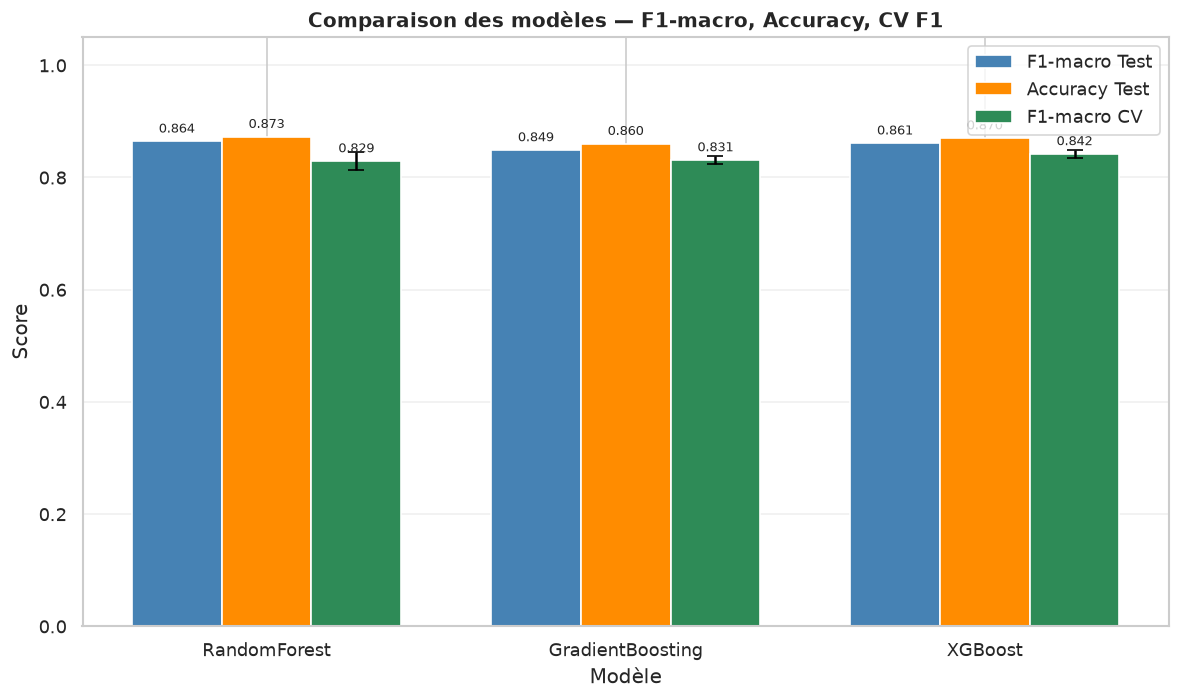

In [19]:
# Visualisation comparaison
model_names = list(results.keys())
f1_scores   = [results[m]['f1_macro'] for m in model_names]
accuracies  = [results[m]['accuracy'] for m in model_names]
cv_f1s      = [results[m]['cv_f1'] for m in model_names]
cv_stds     = [results[m]['cv_std'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, f1_scores,  width, label='F1-macro Test',  color='steelblue')
bars2 = ax.bar(x,          accuracies, width, label='Accuracy Test',  color='darkorange')
bars3 = ax.bar(x + width,  cv_f1s,    width, label='F1-macro CV',    color='seagreen',
               yerr=cv_stds, capsize=5)

ax.set_xlabel('Modèle')
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles — F1-macro, Accuracy, CV F1', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar_group in [bars1, bars2, bars3]:
    for bar in bar_group:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---
## 7. Évaluation du meilleur modèle

### 7.1 Classification Report

In [20]:
best = results[best_name]
print(f'Meilleur modèle : {best_name}')
print(f'F1-macro : {best["f1_macro"]:.4f}  |  Accuracy : {best["accuracy"]:.4f}')
print()
print(classification_report(best['y_test_lbl'], best['y_pred_lbl']))

Meilleur modèle : RandomForest
F1-macro : 0.8642  |  Accuracy : 0.8725

                      precision    recall  f1-score   support

 amelioration_cardio       0.78      0.52      0.62        67
  maintien_bien_etre       0.84      0.80      0.82        59
perte_poids_confirme       0.93      0.93      0.93        30
perte_poids_debutant       0.89      0.98      0.93        87
prise_masse_confirme       0.86      0.97      0.91        98
prise_masse_debutant       0.94      1.00      0.97        59

            accuracy                           0.87       400
           macro avg       0.87      0.87      0.86       400
        weighted avg       0.87      0.87      0.86       400



### 7.2 Matrice de Confusion

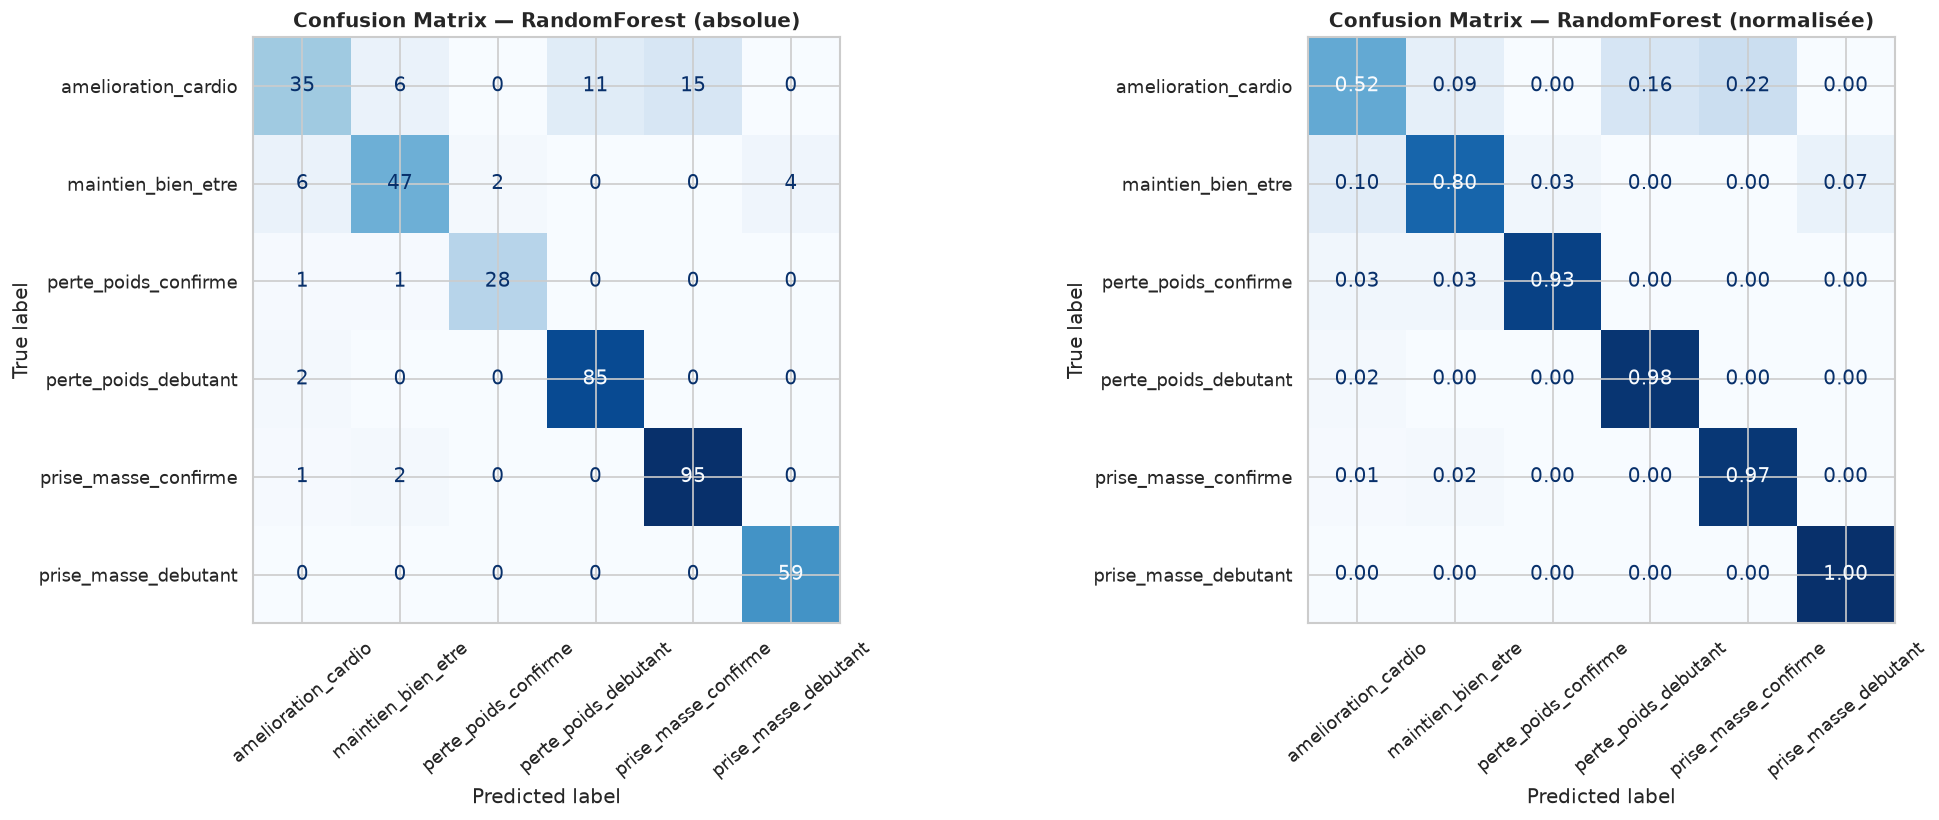


Analyse métier des erreurs :
Les confusions entre profils ADJACENTS (ex: perte_poids_debutant ↔ amelioration_cardio)
sont acceptables : le programme resterait pertinent dans les deux cas.
Les erreurs critiques (perte_poids ↔ prise_masse) doivent être quasi-nulles.


In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

classes = label_encoder.classes_
cm = confusion_matrix(y_test, best['y_pred'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Absolue
disp1 = ConfusionMatrixDisplay(cm, display_labels=classes)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=40)
axes[0].set_title(f'Confusion Matrix — {best_name} (absolue)', fontweight='bold')

# Normalisée
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=classes)
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2f', xticks_rotation=40)
axes[1].set_title(f'Confusion Matrix — {best_name} (normalisée)', fontweight='bold')

plt.tight_layout()
plt.show()

# Analyse métier
print('\nAnalyse métier des erreurs :')
print('Les confusions entre profils ADJACENTS (ex: perte_poids_debutant ↔ amelioration_cardio)')
print('sont acceptables : le programme resterait pertinent dans les deux cas.')
print('Les erreurs critiques (perte_poids ↔ prise_masse) doivent être quasi-nulles.')

### 7.3 Learning Curve


Score train final   : 0.8850
Score val final     : 0.8291
Écart (overfitting) : 0.0559
→ Léger overfitting — acceptable


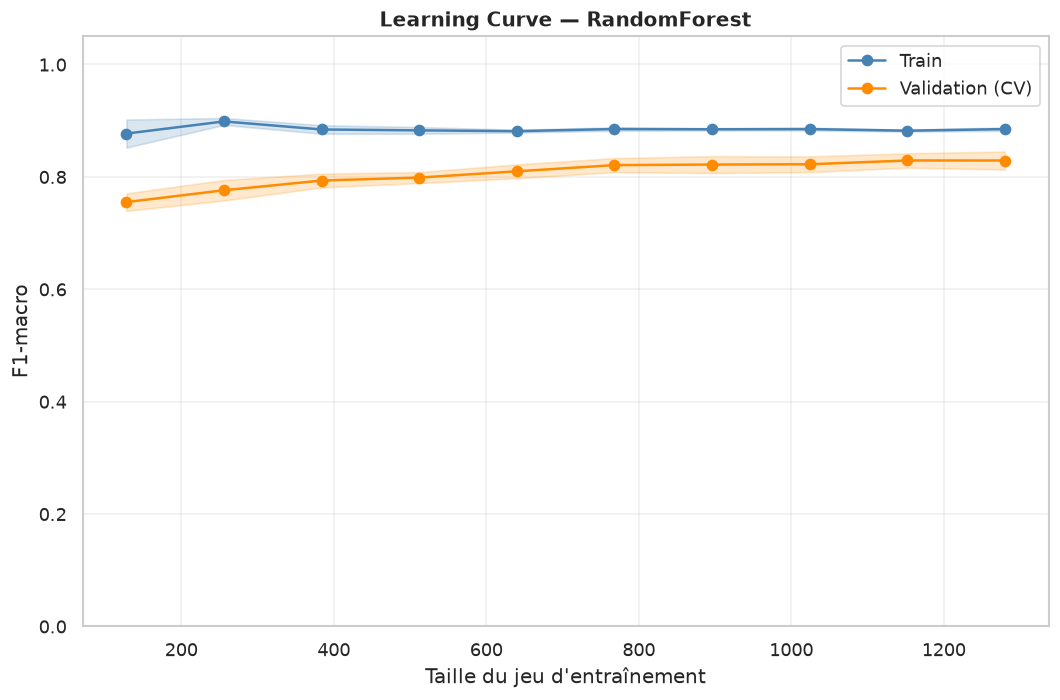

In [22]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best['model'], X_train, y_train,
    cv=cv, scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train', color='steelblue')
ax.fill_between(train_sizes,
                train_scores.mean(1) - train_scores.std(1),
                train_scores.mean(1) + train_scores.std(1),
                alpha=0.2, color='steelblue')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation (CV)', color='darkorange')
ax.fill_between(train_sizes,
                val_scores.mean(1) - val_scores.std(1),
                val_scores.mean(1) + val_scores.std(1),
                alpha=0.2, color='darkorange')
ax.set_xlabel('Taille du jeu d\'entraînement')
ax.set_ylabel('F1-macro')
ax.set_title(f'Learning Curve — {best_name}', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

train_final = train_scores.mean(axis=1)[-1]
val_final   = val_scores.mean(axis=1)[-1]
gap = train_final - val_final
print(f'\nScore train final   : {train_final:.4f}')
print(f'Score val final     : {val_final:.4f}')
print(f'Écart (overfitting) : {gap:.4f}')
if gap < 0.05:
    print('→ Bonne généralisation — pas d\'overfitting significatif')
elif gap < 0.10:
    print('→ Léger overfitting — acceptable')
else:
    print('→ Overfitting détecté — réduire la complexité du modèle')

plt.tight_layout()
plt.show()

---
## 8. Feature Importance & Interprétation

### 8.1 Feature Importance intrinsèque

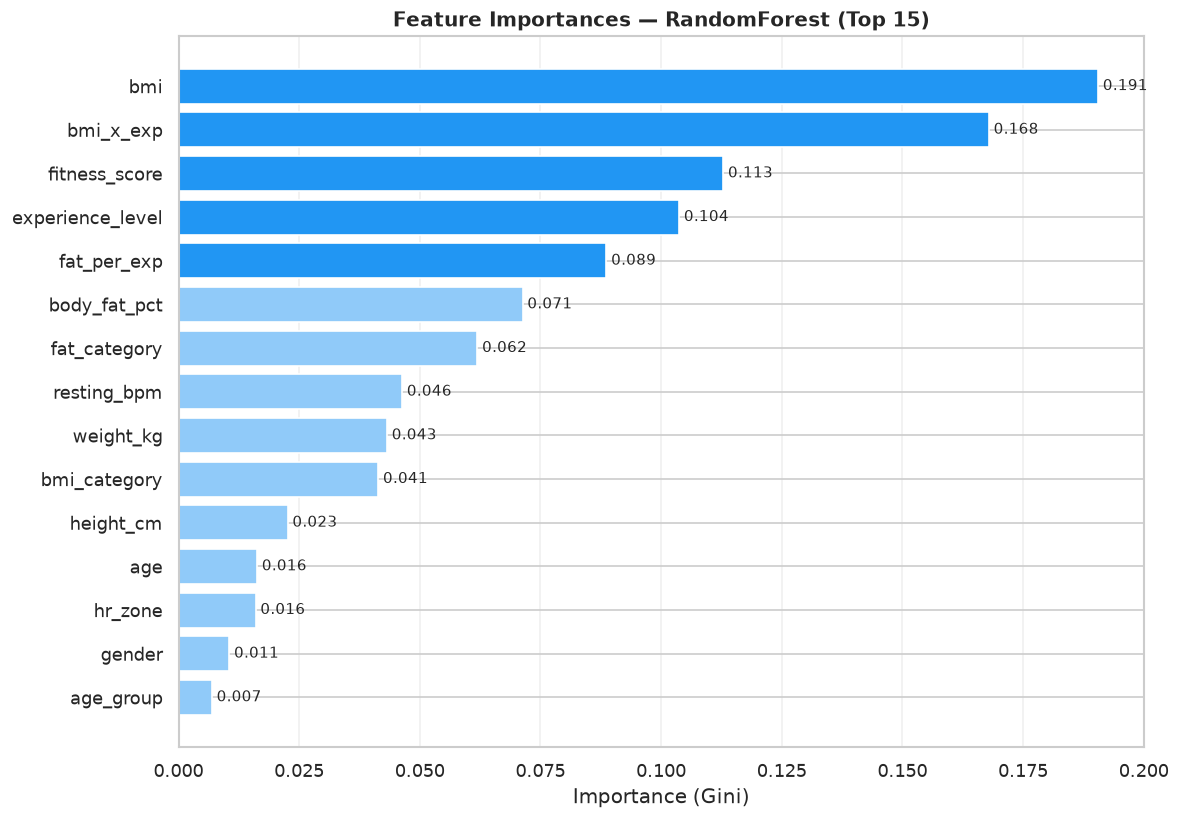


Top 5 features :
  bmi                            0.1905
  bmi_x_exp                      0.1679
  fitness_score                  0.1129
  experience_level               0.1037
  fat_per_exp                    0.0886


In [23]:
clf = best['model'].named_steps['clf']
pre = best['model'].named_steps['pre']

if hasattr(clf, 'feature_importances_'):
    try:
        feat_names = pre.get_feature_names_out()
    except Exception:
        feat_names = get_feature_names()

    importances = clf.feature_importances_
    sorted_idx  = np.argsort(importances)[::-1]

    n_top = min(15, len(feat_names))
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ['#2196F3' if i < 5 else '#90CAF9' for i in range(n_top)]
    ax.barh(
        [feat_names[i] for i in sorted_idx[:n_top]],
        importances[sorted_idx[:n_top]],
        color=colors
    )
    ax.set_xlabel('Importance (Gini)')
    ax.set_title(f'Feature Importances — {best_name} (Top {n_top})', fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')

    for i, idx in enumerate(sorted_idx[:n_top]):
        ax.text(importances[idx] + 0.001, i, f'{importances[idx]:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print('\nTop 5 features :')
    for i in sorted_idx[:5]:
        print(f'  {feat_names[i]:<30} {importances[i]:.4f}')
else:
    print('Ce modèle ne supporte pas feature_importances_')

### 8.2 Permutation Importance

Calcul Permutation Importance (peut prendre 30s) ...


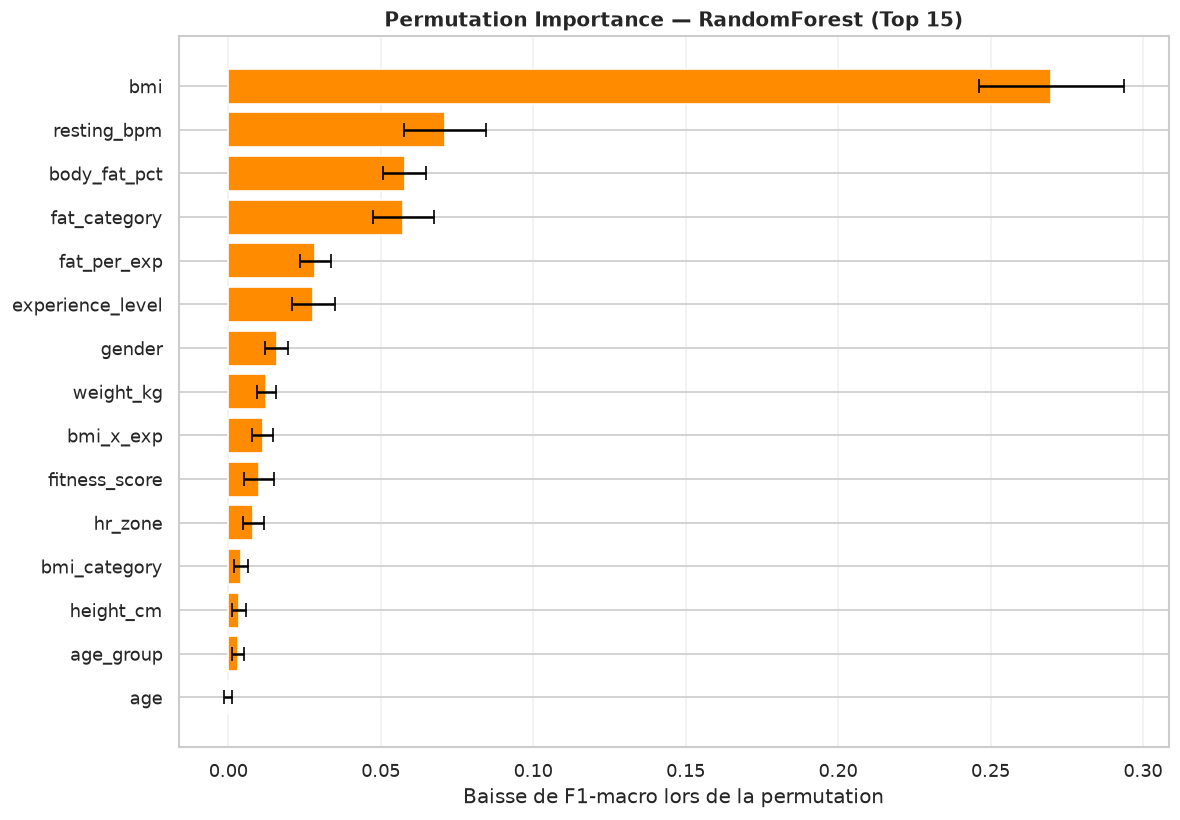


Note : La Permutation Importance est plus fiable que l'importance Gini
pour les features corrélées (BMI et body_fat_pct).


In [24]:
from sklearn.inspection import permutation_importance

print('Calcul Permutation Importance (peut prendre 30s) ...')
perm = permutation_importance(
    best['model'], X_test, y_test,
    n_repeats=20, random_state=42, scoring='f1_macro', n_jobs=-1
)

perm_means  = perm.importances_mean
perm_stds   = perm.importances_std
feat_names_display = get_feature_names()

sorted_perm = np.argsort(perm_means)[::-1]
n_top = min(15, len(feat_names_display))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    [feat_names_display[i] for i in sorted_perm[:n_top]],
    perm_means[sorted_perm[:n_top]],
    xerr=perm_stds[sorted_perm[:n_top]],
    color='darkorange', ecolor='black', capsize=4
)
ax.set_xlabel('Baisse de F1-macro lors de la permutation')
ax.set_title(f'Permutation Importance — {best_name} (Top {n_top})', fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\nNote : La Permutation Importance est plus fiable que l\'importance Gini')
print('pour les features corrélées (BMI et body_fat_pct).')

### 8.3 SHAP — Explicabilité locale et globale

SHAP Beeswarm — importance globale des features (toutes classes agrégées)


TypeError: unhashable type: 'numpy.ndarray'

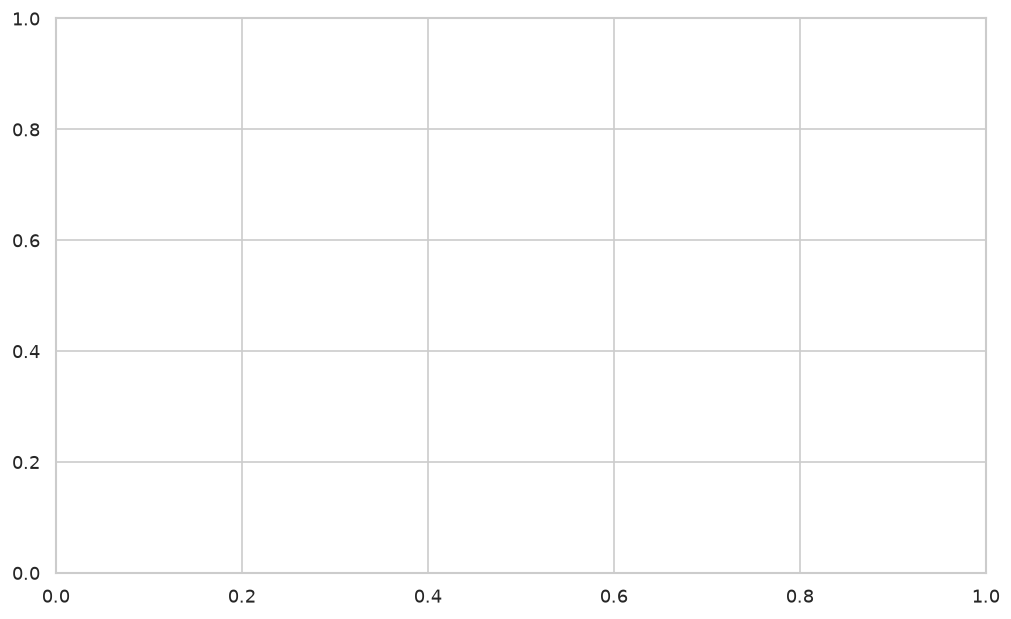

In [25]:
try:
    import shap

    # SHAP sur le pipeline complet
    pre_fitted  = best['model'].named_steps['pre']
    clf_fitted  = best['model'].named_steps['clf']

    X_test_transformed = pre_fitted.transform(X_test)

    explainer   = shap.TreeExplainer(clf_fitted)
    shap_values = explainer.shap_values(X_test_transformed)

    try:
        feat_names_shap = pre_fitted.get_feature_names_out()
    except Exception:
        feat_names_shap = get_feature_names()

    # SHAP Beeswarm global (classe 0)
    print('SHAP Beeswarm — importance globale des features (toutes classes agrégées)')
    shap_abs_mean = np.abs(np.array(shap_values)).mean(axis=(0, 2)) if isinstance(shap_values, list) else np.abs(shap_values).mean(axis=0)
    
    sorted_shap = np.argsort(shap_abs_mean)[::-1]
    n_top = min(12, len(feat_names_shap))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh([feat_names_shap[i] for i in sorted_shap[:n_top]],
            shap_abs_mean[sorted_shap[:n_top]], color='#9c27b0')
    ax.set_xlabel('|SHAP| moyen')
    ax.set_title('SHAP — Impact moyen sur la prédiction (toutes classes)', fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    # Waterfall pour 1 exemple
    print('\nExemple SHAP Waterfall — explication d\'une prédiction individuelle')
    sample_idx = 0
    pred_class = best['y_pred'][sample_idx]
    true_class = y_test[sample_idx]
    print(f'Classe prédite : {label_encoder.classes_[pred_class]}')
    print(f'Classe réelle  : {label_encoder.classes_[true_class]}')

    if isinstance(shap_values, list):
        sv = shap_values[pred_class][sample_idx]
        base = explainer.expected_value[pred_class]
    else:
        sv = shap_values[sample_idx]
        base = explainer.expected_value

    shap_exp = shap.Explanation(
        values=sv,
        base_values=base,
        data=X_test_transformed[sample_idx],
        feature_names=list(feat_names_shap)
    )
    shap.waterfall_plot(shap_exp, max_display=12, show=False)
    plt.title(f'SHAP Waterfall — {label_encoder.classes_[pred_class]}', fontweight='bold')
    plt.tight_layout()
    plt.show()

except ImportError:
    print('SHAP non installé. Installer avec : pip install shap')
    print('Section optionnelle — Feature Importance et Permutation Importance suffisent.')

---
## 9. Sauvegarde du modèle

In [ ]:
import joblib

MODELS_DIR = ROOT / 'ml' / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best['model'],  MODELS_DIR / 'model.pkl')
joblib.dump(label_encoder,  MODELS_DIR / 'encoder.pkl')

print(f'Modèle sauvegardé : {MODELS_DIR}/model.pkl')
print(f'Encoder sauvegardé : {MODELS_DIR}/encoder.pkl')
print(f'\nMeilleur modèle : {best_name}')
print(f'F1-macro : {best["f1_macro"]:.4f}  |  Accuracy : {best["accuracy"]:.4f}')

---
## 10. Test de l'API de recommandation

In [ ]:
from src.recommendation_engine.engine import get_program, list_profiles, program_to_dict

print('Profils disponibles :')
for p in list_profiles():
    print(f'  - {p}')

In [ ]:
# Simulation d'une prédiction complète
import json, os

sample_input = {
    'age': 32,
    'gender': 1,         # homme
    'weight_kg': 88,
    'height_cm': 178,
    'body_fat_pct': 26,
    'resting_bpm': 74,
    'experience_level': 1,
}

bmi = sample_input['weight_kg'] / (sample_input['height_cm'] / 100) ** 2
print(f'BMI calculé : {bmi:.2f}')

# Prédire
row = pd.DataFrame([{**sample_input, 'bmi': round(bmi, 2)}])
row = engineer(row)
from src.preprocessing.pipeline import get_feature_names
X_sample = row[get_feature_names()]

pred_encoded = best['model'].predict(X_sample)[0]
profile = label_encoder.inverse_transform([pred_encoded])[0]
confidence = float(np.max(best['model'].predict_proba(X_sample)))

print(f'\nProfil prédit : {profile}  (confiance : {confidence:.1%})')

# Récupération du programme via BDD (nécessite DATABASE_URL)
try:
    program = get_program(profile)
    output = {
        'profile': profile,
        'confidence': round(confidence, 4),
        'bmi': round(bmi, 2),
        'program': program_to_dict(program)
    }
    print(f'\nProgramme recommandé (BDD) :')
    print(json.dumps(output, indent=2, ensure_ascii=False))
except RuntimeError as e:
    print(f'\n[INFO] BDD non configurée — profil prédit uniquement.')
    print(f'Pour activer les recommandations : export DATABASE_URL=postgresql://...')
    print(f'Profil : {profile} | Confiance : {confidence:.1%} | BMI : {bmi:.2f}')
except Exception as e:
    print(f'\n[WARN] Erreur BDD : {e}')
    print(f'Profil : {profile} | Confiance : {confidence:.1%} | BMI : {bmi:.2f}')

---
## 11. Résumé pour la soutenance

| Élément | Valeur |
|---|---|
| Dataset | Synthétique HealthAI (2000 lignes, distributions cliniques ACSM/OMS) |
| Features utilisées | 8 brutes + 7 engineered = 15 au total |
| Cible | 6 profils fitness (classification multiclasse) |
| Modèles comparés | Random Forest, Gradient Boosting, XGBoost |
| Sélection | F1-macro (StratifiedKFold 5) via RandomizedSearchCV |
| Tracking | MLflow local (runs comparables) |
| Explicabilité | Feature Importance + Permutation Importance + SHAP |
| Sortie API | Profil + programme détaillé (moteur de règles ACSM) |

**Points défendables :**
- Pas de leakage temporel (features disponibles à l'inscription uniquement)
- Labels métier justifiés par guidelines ACSM 2022
- Séparation claire ML (profil) / moteur de règles (programme)
- Analyse métier des erreurs de la Confusion Matrix
- Learning Curve montre l'absence d'overfitting

In [ ]:
mlflow.ui()

In [ ]:
import mlflow

In [ ]:
mlflow ui

In [ ]:
!mlflow ui